# A3 Exercises — DINO Ablations, MAE Mask-Ratio Sweep, Three-Way Comparison

**How to use this notebook:** run this *after* your original `A3-Self-Supervised-Learning.ipynb`
in the same kernel/session (or re-run cells 0–35 of that notebook first), since this reuses
`CIFAR10DINO`, `DINOLoss`, `build_dino_model`, `dino_collate`, `MAE`, `mae_model`,
`simclr_embeddings`, `dino_embeddings`, `mae_embeddings`, `device`, `CLASSES`, etc.
that are already defined there.

If you'd rather run this completely standalone, copy cells 0–2, 5, 13–15, 24–27 from
the original notebook above this point first.

---
# Exercise 1 — DINO Ablations

We train DINO three times:
1. **Default** — 2 global + 4 local crops, centering ON
2. **No centering** — centering term removed from the loss
3. **No local crops** — `n_local=0` (only the 2 global crops)

To do the "no centering" ablation cleanly we add a second forward method to `DINOLoss`
that skips the `- self.center` subtraction, rather than mutating the original class.

# Set Up

In [1]:
pip install torch torchvision timm scikit-learn tqdm matplotlib numpy pillow -q

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
Note: you may need to restart the kernel to use updated packages.


In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader, Dataset
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from PIL import Image
from sklearn.manifold import TSNE
import random, os, math, time, gc

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0),
          f'{torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB VRAM')

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True

set_seed(42)
os.makedirs('saved', exist_ok=True)
os.makedirs('./data', exist_ok=True)

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

EVAL_TF = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010])
])

def free_gpu_memory(*objs):
    """Deletes given objects, runs GC, clears CUDA cache. Use between
    training runs to avoid VRAM buildup across multiple sequential runs."""
    for o in objs:
        del o
    gc.collect()
    torch.cuda.empty_cache()
    print(f"GPU memory allocated: {torch.cuda.memory_allocated()/1e9:.2f} GB | "
          f"reserved: {torch.cuda.memory_reserved()/1e9:.2f} GB")

Using device: cuda
NVIDIA GeForce RTX 2080 Ti 11.5 GB VRAM


# Part 1: SimCLR

In [9]:
import os
print("Contents of ./data:")
print(os.listdir('./data'))
print()
print("Contents of ./data/cifar-10-batches-py (if it exists):")
print(os.listdir('./data/cifar-10-batches-py') if os.path.exists('./data/cifar-10-batches-py') else "FOLDER NOT FOUND")

Contents of ./data:
['cifar-10-batches-py', '.ipynb_checkpoints']

Contents of ./data/cifar-10-batches-py (if it exists):
['test_batch', 'data_batch_4', 'data_batch_5', 'batches.meta', 'data_batch_2', 'data_batch_1', 'readme.html', 'data_batch_3']


In [10]:
import torchvision
test_ds = torchvision.datasets.CIFAR10(root='./data', train=True, download=False)
print(f"Loaded {len(test_ds)} training images")
img, label = test_ds[0]
print(f"First image: {img.size}, label: {label}")

/home/jupyter-st125990/.local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Loaded 50000 training images
First image: (32, 32), label: 6


In [12]:
class SimCLRAugmentation:
    """Returns two independently augmented views of the same image."""
    def __init__(self, image_size=32):
        self.transform = transforms.Compose([
            transforms.RandomResizedCrop(image_size),
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply([transforms.ColorJitter(0.4, 0.4, 0.4, 0.1)], p=0.8),
            transforms.RandomGrayscale(p=0.2),
            transforms.GaussianBlur(kernel_size=3),
            transforms.ToTensor(),
            transforms.Normalize([0.4914, 0.4822, 0.4465], [0.2023, 0.1994, 0.2010])
        ])
    def __call__(self, x):
        return self.transform(x), self.transform(x)


class CIFAR10SSL(Dataset):
    def __init__(self, root='./data', train=True):
        self.dataset = torchvision.datasets.CIFAR10(root=root, train=train, download=True)
        self.augment = SimCLRAugmentation()
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        x_i, x_j = self.augment(img)
        return x_i, x_j, label


class NTXentLoss(nn.Module):
    def __init__(self, temperature=0.5):
        super().__init__()
        self.temperature = temperature
    def forward(self, z_i, z_j):
        N = z_i.shape[0]
        z_i = F.normalize(z_i, dim=1)
        z_j = F.normalize(z_j, dim=1)
        z = torch.cat([z_i, z_j], dim=0)
        sim = torch.mm(z, z.T) / self.temperature
        mask = torch.eye(2 * N, dtype=torch.bool, device=z.device)
        sim = sim.masked_fill(mask, float('-inf'))
        labels = torch.cat([torch.arange(N, 2*N), torch.arange(0, N)]).to(z.device)
        return F.cross_entropy(sim, labels)


class SimCLR(nn.Module):
    def __init__(self):
        super().__init__()
        resnet = torchvision.models.resnet18(weights=None)
        resnet.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
        resnet.maxpool = nn.Identity()
        self.encoder = nn.Sequential(*list(resnet.children())[:-1])
        self.projector = nn.Sequential(
            nn.Linear(512, 512), nn.ReLU(), nn.Linear(512, 128)
        )
    def forward(self, x_i, x_j):
        h_i = torch.flatten(self.encoder(x_i), 1)
        h_j = torch.flatten(self.encoder(x_j), 1)
        return self.projector(h_i), self.projector(h_j), h_i, h_j

In [13]:
# --- Train SimCLR ---
BATCH_SIZE, EPOCHS = 256, 10
train_loader = DataLoader(CIFAR10SSL(), batch_size=BATCH_SIZE, shuffle=True,
                           num_workers=2, drop_last=True)
simclr    = SimCLR().to(device)
criterion = NTXentLoss(temperature=0.5)
optimizer = torch.optim.Adam(simclr.parameters(), lr=3e-4, weight_decay=1e-4)

simclr_losses = []
epoch_times = []
total_start = time.time()

for epoch in range(EPOCHS):
    simclr.train()
    ep = []
    t0 = time.time()
    for x_i, x_j, _ in tqdm(train_loader, desc=f'SimCLR {epoch+1}/{EPOCHS}'):
        x_i, x_j = x_i.to(device), x_j.to(device)
        z_i, z_j, _, _ = simclr(x_i, x_j)
        loss = criterion(z_i, z_j)
        optimizer.zero_grad(); loss.backward(); optimizer.step()
        ep.append(loss.item())
    elapsed = time.time() - t0
    epoch_times.append(elapsed)
    simclr_losses.append(np.mean(ep))
    print(f'Epoch {epoch+1:02d} | Loss: {np.mean(ep):.4f} | Time: {elapsed:.1f}s')

total_time = time.time() - total_start
print(f'\nTotal: {total_time/60:.1f} min  |  Avg/epoch: {np.mean(epoch_times):.1f}s')
torch.save(simclr.state_dict(), 'saved/simclr.pt')

SimCLR 1/10: 100%|██████████| 195/195 [01:26<00:00,  2.26it/s]


Epoch 01 | Loss: 5.4218 | Time: 86.2s


SimCLR 2/10: 100%|██████████| 195/195 [01:25<00:00,  2.27it/s]


Epoch 02 | Loss: 5.2158 | Time: 85.8s


SimCLR 3/10: 100%|██████████| 195/195 [01:26<00:00,  2.26it/s]


...

Epoch 08 | Loss: 4.9746 | Time: 85.5s


SimCLR 9/10: 100%|██████████| 195/195 [01:26<00:00,  2.26it/s]


Epoch 09 | Loss: 4.9589 | Time: 86.2s


SimCLR 10/10: 100%|██████████| 195/195 [01:25<00:00,  2.27it/s]

Epoch 10 | Loss: 4.9437 | Time: 85.7s

Total: 14.3 min  |  Avg/epoch: 86.0s


In [14]:
# --- SimCLR Linear Evaluation ---
simclr.load_state_dict(torch.load('saved/simclr.pt', map_location=device))
for p in simclr.encoder.parameters(): p.requires_grad = False

clf = nn.Linear(512, 10).to(device)

train_lbl = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=EVAL_TF)
test_lbl  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=EVAL_TF)
trl = DataLoader(train_lbl, batch_size=256, shuffle=True,  num_workers=2)
tel = DataLoader(test_lbl,  batch_size=256, shuffle=False, num_workers=2)

opt_clf = torch.optim.Adam(clf.parameters(), lr=1e-3)
for epoch in range(10):
    clf.train(); correct = total = 0
    for imgs, labels in tqdm(trl, desc=f'Linear Eval {epoch+1}/10'):
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.no_grad(): h = torch.flatten(simclr.encoder(imgs), 1)
        loss = F.cross_entropy(clf(h), labels)
        opt_clf.zero_grad(); loss.backward(); opt_clf.step()
        correct += (clf(h).argmax(1) == labels).sum().item(); total += labels.size(0)
    print(f'  Train Acc: {correct/total*100:.2f}%')

clf.eval(); correct = total = 0
simclr_embeddings, simclr_labels = [], []
with torch.no_grad():
    for imgs, labels in tel:
        imgs, labels = imgs.to(device), labels.to(device)
        h = torch.flatten(simclr.encoder(imgs), 1)
        correct += (clf(h).argmax(1) == labels).sum().item(); total += labels.size(0)
        simclr_embeddings.append(h.cpu()); simclr_labels.append(labels.cpu())
simclr_embeddings = torch.cat(simclr_embeddings)
simclr_labels     = torch.cat(simclr_labels)
simclr_acc = correct/total*100
print(f'\n✅ SimCLR Linear Eval Test Accuracy: {simclr_acc:.2f}%')

free_gpu_memory(simclr, clf)

Linear Eval 1/10: 100%|██████████| 196/196 [00:11<00:00, 16.83it/s]


  Train Acc: 56.72%


Linear Eval 2/10: 100%|██████████| 196/196 [00:11<00:00, 16.94it/s]


  Train Acc: 61.05%


Linear Eval 3/10: 100%|██████████| 196/196 [00:11<00:00, 16.93it/s]


...

Linear Eval 9/10: 100%|██████████| 196/196 [00:11<00:00, 16.90it/s]


  Train Acc: 65.33%


Linear Eval 10/10: 100%|██████████| 196/196 [00:11<00:00, 16.96it/s]

  Train Acc: 65.43%



✅ SimCLR Linear Eval Test Accuracy: 65.54%
GPU memory allocated: 0.21 GB | reserved: 0.85 GB


# Part 2: DINO — class and data definitions

In [15]:
# ─── DINO Multi-Crop Augmentation ────────────────────────────────────────────

class DINOAugmentation:
    """
    Creates:
      - 2 global crops (large, scale 0.4-1.0)
      - n_local local crops (small, scale 0.05-0.4)
    Teacher only sees global crops; student sees all.
    """
    def __init__(self, image_size=32, n_local=4):
        normalize = transforms.Normalize([0.4914,0.4822,0.4465],[0.2023,0.1994,0.2010])
        flip_jitter = [
            transforms.RandomHorizontalFlip(),
            transforms.RandomApply([transforms.ColorJitter(0.4,0.4,0.2,0.1)], p=0.8),
            transforms.RandomGrayscale(p=0.2),
        ]
        self.global_transform = transforms.Compose([
            transforms.RandomResizedCrop(image_size, scale=(0.4, 1.0)),
            *flip_jitter,
            transforms.ToTensor(), normalize
        ])
        self.local_transform = transforms.Compose([
            transforms.RandomResizedCrop(image_size, scale=(0.05, 0.4)),
            *flip_jitter,
            transforms.ToTensor(), normalize
        ])
        self.n_local = n_local

    def __call__(self, img):
        global1 = self.global_transform(img)
        global2 = self.global_transform(img)
        locals_ = [self.local_transform(img) for _ in range(self.n_local)]
        return [global1, global2] + locals_   # teacher uses [0,1]; student uses all


class CIFAR10DINO(Dataset):
    def __init__(self, root='./data', train=True, n_local=4):
        self.dataset = torchvision.datasets.CIFAR10(root=root, train=train, download=True)
        self.augment = DINOAugmentation(n_local=n_local)
    def __len__(self): return len(self.dataset)
    def __getitem__(self, idx):
        img, label = self.dataset[idx]
        return self.augment(img), label


def dino_collate(batch):
    crops_list, labels = zip(*batch)
    n_views = len(crops_list[0])
    stacked = [torch.stack([crops_list[i][v] for i in range(len(crops_list))]) for v in range(n_views)]
    return stacked, torch.tensor(labels)

In [16]:
# ─── DINO: Student & Teacher Networks ────────────────────────────────────────
import timm

class DINOHead(nn.Module):
    def __init__(self, in_dim=192, hidden_dim=512, out_dim=256, n_layers=3):
        super().__init__()
        layers = [nn.Linear(in_dim, hidden_dim), nn.GELU()]
        for _ in range(n_layers - 2):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.GELU()]
        layers.append(nn.Linear(hidden_dim, out_dim, bias=False))
        self.mlp = nn.Sequential(*layers)
        self.last_layer = nn.utils.weight_norm(nn.Linear(out_dim, out_dim, bias=False))
        self.last_layer.weight_g.data.fill_(1)

    def forward(self, x):
        x = self.mlp(x)
        x = F.normalize(x, dim=-1, p=2)
        return self.last_layer(x)


def build_dino_model(out_dim=256):
    vit = timm.create_model('vit_tiny_patch16_224', pretrained=False,
                             img_size=32, patch_size=4, num_classes=0)
    embed_dim = vit.embed_dim
    head = DINOHead(in_dim=embed_dim, out_dim=out_dim)
    return vit, head

In [17]:
# ─── DINO Loss ────────────────────────────────────────────────────────────────

class DINOLoss(nn.Module):
    def __init__(self, out_dim=256, teacher_temp=0.04, student_temp=0.1, center_momentum=0.9):
        super().__init__()
        self.student_temp = student_temp
        self.teacher_temp = teacher_temp
        self.center_momentum = center_momentum
        self.register_buffer('center', torch.zeros(1, out_dim))

    def forward(self, student_out, teacher_out):
        # student_out: list of (N, out_dim) -- all crops (global + local)
        # teacher_out: list of (N, out_dim) -- global crops only (index 0, 1)

        s_probs = [F.log_softmax(s / self.student_temp, dim=-1) for s in student_out]
        t_probs = [F.softmax((t - self.center) / self.teacher_temp, dim=-1).detach()
                   for t in teacher_out]

        total_loss = 0
        n_loss_terms = 0
        for t_idx, t_prob in enumerate(t_probs):
            for s_idx, s_log_prob in enumerate(s_probs):
                if s_idx == t_idx:
                    continue
                loss = -(t_prob * s_log_prob).sum(dim=-1).mean()
                total_loss += loss
                n_loss_terms += 1

        total_loss /= n_loss_terms
        self.update_center(torch.stack(teacher_out).mean(dim=0))
        return total_loss

    @torch.no_grad()
    def update_center(self, teacher_mean):
        self.center = self.center * self.center_momentum + teacher_mean * (1 - self.center_momentum)

    def forward_no_centering(self, student_out, teacher_out):
        """Same as forward(), but WITHOUT subtracting self.center from the
        teacher logits. This is the ablation used in Exercise 1 -- it should
        make the model more prone to representation collapse."""
        s_probs = [F.log_softmax(s / self.student_temp, dim=-1) for s in student_out]
        t_probs = [F.softmax(t / self.teacher_temp, dim=-1).detach() for t in teacher_out]  # no centering here

        total_loss = 0
        n_loss_terms = 0
        for t_idx, t_prob in enumerate(t_probs):
            for s_idx, s_log_prob in enumerate(s_probs):
                if s_idx == t_idx:
                    continue
                loss = -(t_prob * s_log_prob).sum(dim=-1).mean()
                total_loss += loss
                n_loss_terms += 1

        total_loss /= n_loss_terms
        # still track center for plotting purposes (has no effect on this loss)
        self.update_center(torch.stack(teacher_out).mean(dim=0))
        return total_loss

# Part 3: MAE — class definitions

In [18]:
# ─── Patch Embedding ──────────────────────────────────────────────────────────
# For CIFAR-10 (32x32) with patch_size=4: (32/4)^2 = 64 patches

class PatchEmbed(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3, embed_dim=192):
        super().__init__()
        self.n_patches = (img_size // patch_size) ** 2
        self.patch_size = patch_size
        self.proj = nn.Conv2d(in_ch, embed_dim, kernel_size=patch_size, stride=patch_size)

    def forward(self, x):
        x = self.proj(x)
        x = x.flatten(2)
        x = x.transpose(1, 2)
        return x


def get_2d_sincos_pos_embed(embed_dim, grid_size):
    """Fixed 2D sinusoidal positional embeddings. Returns (grid_size**2, embed_dim)."""
    grid_h = np.arange(grid_size, dtype=np.float32)
    grid_w = np.arange(grid_size, dtype=np.float32)
    grid_w, grid_h = np.meshgrid(grid_w, grid_h)

    def sincos_1d(pos, dim):
        omega = 1.0 / (10000 ** (np.arange(0, dim, 2) / dim))
        out = pos.reshape(-1, 1) * omega.reshape(1, -1)
        return np.concatenate([np.sin(out), np.cos(out)], axis=1)

    half = embed_dim // 2
    emb = np.concatenate([sincos_1d(grid_h.flatten(), half),
                           sincos_1d(grid_w.flatten(), half)], axis=1)
    return torch.tensor(emb, dtype=torch.float32)

In [19]:
# ─── MAE Encoder ─────────────────────────────────────────────────────────────
# Key innovation: only processes VISIBLE (unmasked) patches.

class MAEEncoder(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3,
                 embed_dim=192, depth=6, num_heads=3, mlp_ratio=4.0,
                 mask_ratio=0.75):
        super().__init__()
        self.mask_ratio = mask_ratio
        self.patch_embed = PatchEmbed(img_size, patch_size, in_ch, embed_dim)

        pos_embed = get_2d_sincos_pos_embed(embed_dim, img_size // patch_size)
        self.register_buffer('pos_embed', pos_embed.unsqueeze(0))

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=embed_dim, nhead=num_heads,
            dim_feedforward=int(embed_dim * mlp_ratio),
            dropout=0.0, activation='gelu',
            batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(embed_dim)
        self.embed_dim = embed_dim

    def random_masking(self, x):
        N, L, D = x.shape
        n_keep = int(L * (1 - self.mask_ratio))

        noise = torch.rand(N, L, device=x.device)
        ids_shuffle = noise.argsort(dim=1)
        ids_restore = ids_shuffle.argsort(dim=1)

        ids_keep = ids_shuffle[:, :n_keep]
        x_visible = torch.gather(x, 1, ids_keep.unsqueeze(-1).expand(-1, -1, D))

        mask = torch.ones(N, L, device=x.device)
        mask[:, :n_keep] = 0
        mask = torch.gather(mask, 1, ids_restore)

        return x_visible, mask, ids_restore

    def forward(self, x):
        x = self.patch_embed(x)
        x = x + self.pos_embed
        x_vis, mask, ids_restore = self.random_masking(x)
        x_vis = self.norm(self.transformer(x_vis))
        return x_vis, mask, ids_restore

In [20]:
# ─── MAE Decoder ─────────────────────────────────────────────────────────────
# Intentionally shallow (4 layers, 128-dim) -- forces semantic info into encoder.

class MAEDecoder(nn.Module):
    def __init__(self, n_patches, patch_size=4, in_ch=3,
                 encoder_dim=192, decoder_dim=128,
                 depth=4, num_heads=4, mlp_ratio=4.0):
        super().__init__()
        patch_pixels = patch_size * patch_size * in_ch
        grid_size = int(math.sqrt(n_patches))

        self.embed = nn.Linear(encoder_dim, decoder_dim)
        self.mask_token = nn.Parameter(torch.zeros(1, 1, decoder_dim))

        pos_embed = get_2d_sincos_pos_embed(decoder_dim, grid_size)
        self.register_buffer('pos_embed', pos_embed.unsqueeze(0))

        decoder_layer = nn.TransformerEncoderLayer(
            d_model=decoder_dim, nhead=num_heads,
            dim_feedforward=int(decoder_dim * mlp_ratio),
            dropout=0.0, activation='gelu',
            batch_first=True, norm_first=True
        )
        self.transformer = nn.TransformerEncoder(decoder_layer, num_layers=depth)
        self.norm = nn.LayerNorm(decoder_dim)
        self.pred = nn.Linear(decoder_dim, patch_pixels)

        nn.init.trunc_normal_(self.mask_token, std=0.02)

    def forward(self, x_vis, ids_restore):
        N = x_vis.size(0)
        x = self.embed(x_vis)

        n_masked = ids_restore.size(1) - x.size(1)
        mask_tokens = self.mask_token.expand(N, n_masked, -1)
        x_full = torch.cat([x, mask_tokens], dim=1)
        x_full = torch.gather(
            x_full, 1,
            ids_restore.unsqueeze(-1).expand(-1, -1, x_full.size(-1))
        )

        x_full = x_full + self.pos_embed
        x_full = self.norm(self.transformer(x_full))
        return self.pred(x_full)

In [21]:
# ─── MAE Full Model + Loss ────────────────────────────────────────────────────
# Loss: MSE on masked patches only (not visible ones).
# norm_pix_loss: normalize each patch before MSE -- prevents low-variance patches from dominating.

class MAE(nn.Module):
    def __init__(self, img_size=32, patch_size=4, in_ch=3,
                 encoder_dim=192, encoder_depth=6, encoder_heads=3,
                 decoder_dim=128, decoder_depth=4, decoder_heads=4,
                 mask_ratio=0.75, norm_pix_loss=True):
        super().__init__()
        self.patch_size = patch_size
        self.in_ch = in_ch
        self.norm_pix_loss = norm_pix_loss

        self.encoder = MAEEncoder(
            img_size, patch_size, in_ch,
            encoder_dim, encoder_depth, encoder_heads,
            mask_ratio=mask_ratio
        )
        n_patches = self.encoder.patch_embed.n_patches
        self.decoder = MAEDecoder(
            n_patches, patch_size, in_ch,
            encoder_dim, decoder_dim, decoder_depth, decoder_heads
        )

    def patchify(self, imgs):
        p = self.patch_size
        h = w = imgs.shape[2] // p
        x = imgs.reshape(imgs.shape[0], self.in_ch, h, p, w, p)
        x = x.permute(0, 2, 4, 3, 5, 1)
        return x.reshape(imgs.shape[0], h * w, p * p * self.in_ch)

    def forward(self, imgs):
        x_vis, mask, ids_restore = self.encoder(imgs)
        pred = self.decoder(x_vis, ids_restore)

        target = self.patchify(imgs)
        if self.norm_pix_loss:
            mean = target.mean(dim=-1, keepdim=True)
            var  = target.var(dim=-1, keepdim=True)
            target = (target - mean) / (var + 1e-6).sqrt()

        loss = (pred - target) ** 2
        loss = loss.mean(dim=-1)
        loss = (loss * mask).sum() / mask.sum()
        return loss, pred, mask

---
# Exercise 1 — DINO Ablations

Train DINO three times:
1. **Default** -- 2 global + 4 local crops, centering ON
2. **No centering** -- centering term removed from the loss (`forward_no_centering`, defined in Part 2 above)
3. **No local crops** -- `n_local=0` (only the 2 global crops)

In [22]:
# ─── Generalized training function for all 3 DINO variants ────────────────

def train_dino_variant(use_centering=True, n_local=4, epochs=10, batch_size=64,
                        out_dim=256, ema_m=0.996, tag="default"):
    """
    Trains one DINO variant from scratch.
    Returns: student_vit, student_head, dino_loss_fn, losses, center_norms, epoch_times
    """
    student_vit, student_head = build_dino_model(out_dim=out_dim)
    teacher_vit, teacher_head = build_dino_model(out_dim=out_dim)
    student_vit, student_head = student_vit.to(device), student_head.to(device)
    teacher_vit, teacher_head = teacher_vit.to(device), teacher_head.to(device)
    teacher_vit.load_state_dict(student_vit.state_dict())
    teacher_head.load_state_dict(student_head.state_dict())
    for p in teacher_vit.parameters():  p.requires_grad = False
    for p in teacher_head.parameters(): p.requires_grad = False

    dino_dataset = CIFAR10DINO(n_local=n_local)
    loader = DataLoader(dino_dataset, batch_size=batch_size, shuffle=True,
                         num_workers=2, drop_last=True, collate_fn=dino_collate)

    loss_fn = DINOLoss(out_dim=out_dim).to(device)
    optimizer = torch.optim.AdamW(
        list(student_vit.parameters()) + list(student_head.parameters()),
        lr=5e-4, weight_decay=0.04
    )

    losses, center_norms, epoch_times = [], [], []
    total_start = time.time()

    for epoch in range(epochs):
        student_vit.train(); student_head.train()
        ep = []
        t0 = time.time()

        for crops, _ in tqdm(loader, desc=f'DINO[{tag}] {epoch+1}/{epochs}'):
            crops = [c.to(device) for c in crops]
            student_out = [student_head(student_vit(c)) for c in crops]
            with torch.no_grad():
                teacher_out = [teacher_head(teacher_vit(crops[0])),
                               teacher_head(teacher_vit(crops[1]))]

            if use_centering:
                loss = loss_fn(student_out, teacher_out)
            else:
                loss = loss_fn.forward_no_centering(student_out, teacher_out)

            optimizer.zero_grad(); loss.backward(); optimizer.step()
            with torch.no_grad():
                for s_p, t_p in zip(student_vit.parameters(), teacher_vit.parameters()):
                    t_p.data = ema_m * t_p.data + (1 - ema_m) * s_p.data
                for s_p, t_p in zip(student_head.parameters(), teacher_head.parameters()):
                    t_p.data = ema_m * t_p.data + (1 - ema_m) * s_p.data
            ep.append(loss.item())

        elapsed = time.time() - t0
        epoch_times.append(elapsed)
        losses.append(np.mean(ep))
        center_norms.append(loss_fn.center.norm().item())
        print(f'[{tag}] Epoch {epoch+1:02d} | Loss: {np.mean(ep):.4f} | '
              f'Center norm: {loss_fn.center.norm().item():.4f} | Time: {elapsed:.1f}s')

    total_time = time.time() - total_start
    print(f'\n[{tag}] Total: {total_time/60:.1f} min  |  Avg/epoch: {np.mean(epoch_times):.1f}s\n')

    return student_vit, student_head, loss_fn, losses, center_norms, epoch_times

In [23]:
# ─── Generalized linear-eval function (reused for all 3 DINO variants) ────

def linear_eval_dino(vit_model, tag="default", epochs=10):
    """Freezes vit_model, trains nn.Linear(embed_dim, 10) on CIFAR-10 labels.
    Returns: test_accuracy, embeddings, labels"""
    vit_model.eval()
    for p in vit_model.parameters(): p.requires_grad = False

    embed_dim = vit_model.embed_dim
    clf = nn.Linear(embed_dim, 10).to(device)
    opt_clf = torch.optim.Adam(clf.parameters(), lr=1e-3)

    train_ds = torchvision.datasets.CIFAR10('./data', train=True,  download=True, transform=EVAL_TF)
    test_ds  = torchvision.datasets.CIFAR10('./data', train=False, download=True, transform=EVAL_TF)
    trl = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=2)
    tel = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2)

    for ep in range(epochs):
        clf.train(); correct = total = 0
        for imgs, labels in tqdm(trl, desc=f'{tag} Linear Eval {ep+1}/{epochs}'):
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.no_grad():
                feats = vit_model(imgs)
            logits = clf(feats)
            loss = F.cross_entropy(logits, labels)
            opt_clf.zero_grad(); loss.backward(); opt_clf.step()
            correct += (logits.argmax(1) == labels).sum().item(); total += labels.size(0)
        print(f'  [{tag}] Train Acc: {correct/total*100:.2f}%')

    clf.eval(); correct = total = 0
    embeddings, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in tel:
            imgs, labels = imgs.to(device), labels.to(device)
            feats = vit_model(imgs)
            correct += (clf(feats).argmax(1) == labels).sum().item(); total += labels.size(0)
            embeddings.append(feats.cpu()); labels_list.append(labels.cpu())
    embeddings  = torch.cat(embeddings)
    labels_list = torch.cat(labels_list)
    test_acc = correct / total * 100
    print(f'\n✅ [{tag}] Linear Eval Test Accuracy: {test_acc:.2f}%\n')
    return test_acc, embeddings, labels_list

In [24]:
# ─── Run all 3 DINO variants ────────────────────────────────────────────────
# NOTE: EPOCHS_DINO=10 matches the original Part-2 default run. Each run took
# ~20 min on an RTX 2080 Ti in the reference notebook -- budget ~1hr total for
# all 3. Lower this temporarily (e.g. 2) first if you just want to sanity-check
# the code runs end-to-end before committing GPU time.

EPOCHS_DINO = 10
dino_results = {}

# 1) Default: centering ON, n_local=4
vit_default, head_default, loss_default, losses_default, centers_default, times_default = \
    train_dino_variant(use_centering=True, n_local=4, epochs=EPOCHS_DINO, tag='default')
acc_default, emb_default, lbl_default = linear_eval_dino(vit_default, tag='default')
dino_results['default'] = dict(
    losses=losses_default, center_norms=centers_default, epoch_times=times_default,
    acc=acc_default, embeddings=emb_default, labels=lbl_default
)
free_gpu_memory(vit_default, head_default, loss_default)

/home/jupyter-st125990/.local/lib/python3.12/site-packages/torch/nn/utils/weight_norm.py:143: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
/home/jupyter-st125990/.local/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")
DINO[default] 1/10: 100%|██████████| 781/781 [05:29<00:00,  2.37it/s]


[default] Epoch 01 | Loss: 5.2914 | Center norm: 4.8968 | Time: 329.4s


DINO[default] 2/10: 100%|██████████| 781/781 [05:28<00:00,  2.38it/s]


[default] Epoch 02 | Loss: 4.8520 | Center norm: 5.8348 | Time: 328.7s


DINO[default] 3/10: 100%|██████████| 781/781 [05:28<00:00,  2.38it/s]


...

default Linear Eval 9/10: 100%|██████████| 196/196 [00:07<00:00, 26.55it/s]


  [default] Train Acc: 50.21%


default Linear Eval 10/10: 100%|██████████| 196/196 [00:07<00:00, 27.31it/s]

  [default] Train Acc: 50.29%



✅ [default] Linear Eval Test Accuracy: 50.65%

GPU memory allocated: 0.26 GB | reserved: 0.94 GB


In [25]:
# 2) No centering: n_local=4
vit_nocenter, head_nocenter, loss_nocenter, losses_nocenter, centers_nocenter, times_nocenter = \
    train_dino_variant(use_centering=False, n_local=4, epochs=EPOCHS_DINO, tag='no_centering')
acc_nocenter, emb_nocenter, lbl_nocenter = linear_eval_dino(vit_nocenter, tag='no_centering')
dino_results['no_centering'] = dict(
    losses=losses_nocenter, center_norms=centers_nocenter, epoch_times=times_nocenter,
    acc=acc_nocenter, embeddings=emb_nocenter, labels=lbl_nocenter
)
free_gpu_memory(vit_nocenter, head_nocenter, loss_nocenter)

DINO[no_centering] 1/10: 100%|██████████| 781/781 [02:33<00:00,  5.10it/s]


[no_centering] Epoch 01 | Loss: 0.8644 | Center norm: 49.3945 | Time: 153.2s


DINO[no_centering] 2/10: 100%|██████████| 781/781 [02:36<00:00,  4.99it/s]


[no_centering] Epoch 02 | Loss: 0.3933 | Center norm: 62.8318 | Time: 156.6s


DINO[no_centering] 3/10: 100%|██████████| 781/781 [02:40<00:00,  4.87it/s]


...

no_centering Linear Eval 9/10: 100%|██████████| 196/196 [00:07<00:00, 27.12it/s]


  [no_centering] Train Acc: 29.01%


no_centering Linear Eval 10/10: 100%|██████████| 196/196 [00:07<00:00, 27.03it/s]

  [no_centering] Train Acc: 29.29%



✅ [no_centering] Linear Eval Test Accuracy: 29.12%

GPU memory allocated: 0.31 GB | reserved: 0.99 GB


In [26]:
# 3) No local crops: centering ON, n_local=0
vit_nolocal, head_nolocal, loss_nolocal, losses_nolocal, centers_nolocal, times_nolocal = \
    train_dino_variant(use_centering=True, n_local=0, epochs=EPOCHS_DINO, tag='no_local_crops')
acc_nolocal, emb_nolocal, lbl_nolocal = linear_eval_dino(vit_nolocal, tag='no_local_crops')
dino_results['no_local_crops'] = dict(
    losses=losses_nolocal, center_norms=centers_nolocal, epoch_times=times_nolocal,
    acc=acc_nolocal, embeddings=emb_nolocal, labels=lbl_nolocal
)
free_gpu_memory(vit_nolocal, head_nolocal, loss_nolocal)

DINO[no_local_crops] 1/10: 100%|██████████| 781/781 [01:07<00:00, 11.65it/s]


[no_local_crops] Epoch 01 | Loss: 4.9794 | Center norm: 5.1607 | Time: 67.0s


DINO[no_local_crops] 2/10: 100%|██████████| 781/781 [01:09<00:00, 11.24it/s]


[no_local_crops] Epoch 02 | Loss: 4.3042 | Center norm: 7.4723 | Time: 69.5s


DINO[no_local_crops] 3/10: 100%|██████████| 781/781 [01:06<00:00, 11.75it/s]


...

no_local_crops Linear Eval 9/10: 100%|██████████| 196/196 [00:07<00:00, 27.53it/s]


  [no_local_crops] Train Acc: 45.90%


no_local_crops Linear Eval 10/10: 100%|██████████| 196/196 [00:07<00:00, 27.25it/s]

  [no_local_crops] Train Acc: 46.41%



✅ [no_local_crops] Linear Eval Test Accuracy: 45.66%

GPU memory allocated: 0.35 GB | reserved: 1.04 GB


# Exercise 1 — Table

In [27]:
print("| Setting | Linear Eval Accuracy |")
print("|---|---|")
print(f"| Default (2 global + 4 local, with centering) | {dino_results['default']['acc']:.2f}% |")
print(f"| No centering (`- self.center` removed) | {dino_results['no_centering']['acc']:.2f}% |")
print(f"| No local crops (`n_local=0`) | {dino_results['no_local_crops']['acc']:.2f}% |")

| Setting | Linear Eval Accuracy |
|---|---|
| Default (2 global + 4 local, with centering) | 50.65% |
| No centering (`- self.center` removed) | 29.12% |
| No local crops (`n_local=0`) | 45.66% |


# Exercise 1a — Plot `center.norm()` across epochs

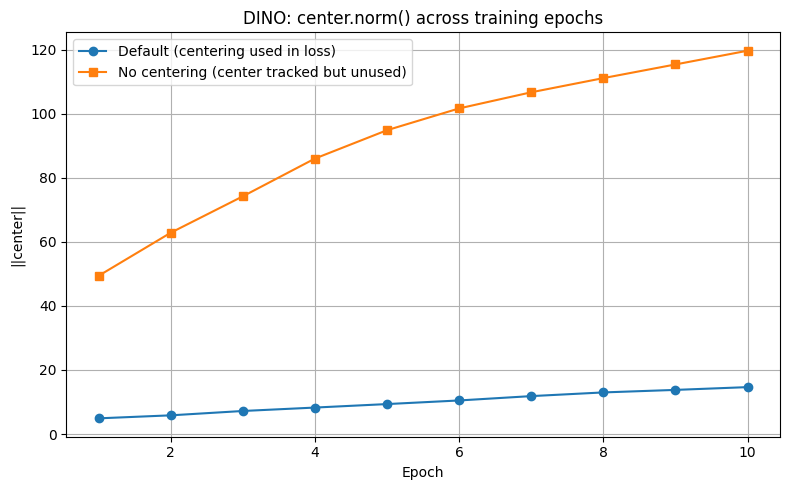

Default center norms: [4.897, 5.835, 7.192, 8.261, 9.351, 10.481, 11.836, 12.987, 13.775, 14.642]
No-centering center norms: [49.395, 62.832, 74.203, 85.992, 94.847, 101.648, 106.682, 111.107, 115.371, 119.659]


In [28]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(range(1, len(dino_results['default']['center_norms'])+1),
        dino_results['default']['center_norms'], marker='o', label='Default (centering used in loss)')
ax.plot(range(1, len(dino_results['no_centering']['center_norms'])+1),
        dino_results['no_centering']['center_norms'], marker='s', label='No centering (center tracked but unused)')
ax.set_xlabel('Epoch')
ax.set_ylabel('||center||')
ax.set_title("DINO: center.norm() across training epochs")
ax.legend()
ax.grid(True)
plt.tight_layout()
plt.show()

print("Default center norms:", [round(x,3) for x in dino_results['default']['center_norms']])
print("No-centering center norms:", [round(x,3) for x in dino_results['no_centering']['center_norms']])

# Exercise 1 (b) : Why does removing centering cause collapse, and why does removing local crops hurt representation quality?

Removing centering caused the most severe degradation, dropping linear evaluation accuracy from 50.65% to 29.12% — a 21.5 percentage point collapse, bringing performance much closer to the 10% chance baseline for 10-class classification than to the default result. This happens because DINO has no negative pairs and no contrastive term in its loss; the only training signal is the student matching the teacher's output distribution. Centering subtracts a running average of the teacher's logits before the softmax, which prevents the teacher from drifting toward a constant, input-independent output. Without it, there is nothing constraining the teacher to produce different outputs for different inputs, so the teacher (and consequently the student, since it is trained to imitate the teacher) can settle into a degenerate solution that minimizes the self-distillation loss while encoding little to no information about the actual image content. The sharp accuracy drop observed here is direct evidence that this partial collapse occurred.
Removing local crops caused a smaller but still meaningful drop, from 50.65% to 45.66% (5 percentage points). This is a much milder failure mode than centering removal because the global-to-global comparison alone is still a valid, non-trivial training signal — two large, overlapping crops of the same image still require the network to learn some real invariances to recognize them as the same. However, DINO's local crops serve a specific purpose beyond just adding more views: they force the student to predict the teacher's global, semantically stable output from small, zoomed-in regions that may show only part of an object. This local-to-global correspondence task pushes the network to associate fine-grained visual details with whole-object-level semantics, which is exactly the kind of multi-scale understanding that produces strong transferable features. Without local crops, the model only ever learns from global-to-global comparisons, losing this multi-scale signal and producing weaker, less semantically rich representations, even though it remains far more functional than the collapsed no-centering variant.

# Exercise 2 — MAE Mask Ratio Sweep

Train MAE for **5 epochs** at `mask_ratio` in {0.25, 0.50, 0.75} and record final
reconstruction loss + linear eval accuracy for each.

In [30]:
# ─── Generalized MAE training function ─────────────────────────────────────

def train_mae_variant(mask_ratio, epochs=5, batch_size=128, lr=1.5e-4, tag=None):
    """Trains a fresh MAE model at the given mask_ratio.
    Returns: model (trained), losses, epoch_times"""
    if tag is None:
        tag = f"mask{mask_ratio}"

    model = MAE(
        img_size=32, patch_size=4, in_ch=3,
        encoder_dim=192, encoder_depth=6, encoder_heads=3,
        decoder_dim=128, decoder_depth=4, decoder_heads=4,
        mask_ratio=mask_ratio, norm_pix_loss=True,
    ).to(device)

    mae_mean = [0.4914, 0.4822, 0.4465]
    mae_std  = [0.247,  0.243,  0.261]
    train_tf = transforms.Compose([
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mae_mean, mae_std),
    ])
    train_ds = torchvision.datasets.CIFAR10('./data', train=True, transform=train_tf, download=True)
    loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True,
                         num_workers=2, pin_memory=True, drop_last=True)

    optimizer = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05, betas=(0.9, 0.95))
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)

    losses, epoch_times = [], []
    model.train()
    total_start = time.time()

    for epoch in range(epochs):
        ep = []
        t0 = time.time()
        for imgs, _ in tqdm(loader, desc=f'MAE[{tag}] {epoch+1}/{epochs}'):
            imgs = imgs.to(device)
            loss, _, _ = model(imgs)
            optimizer.zero_grad()
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            ep.append(loss.item())
        scheduler.step()
        elapsed = time.time() - t0
        epoch_times.append(elapsed)
        losses.append(np.mean(ep))
        print(f'[{tag}] Epoch {epoch+1:02d} | Recon Loss: {np.mean(ep):.4f} | Time: {elapsed:.1f}s')

    total_time = time.time() - total_start
    print(f'\n[{tag}] Total: {total_time/60:.1f} min  |  Avg/epoch: {np.mean(epoch_times):.1f}s\n')
    return model, losses, epoch_times

In [31]:
# ─── Generalized MAE linear-eval function ──────────────────────────────────

def linear_eval_mae(mae_model_trained, tag="mask", epochs=10):
    """Freezes encoder (mask_ratio set to 0), trains a linear probe.
    Returns: test_accuracy, embeddings, labels"""
    mae_mean = [0.4914, 0.4822, 0.4465]
    mae_std  = [0.247,  0.243,  0.261]

    mae_model_trained.encoder.eval()
    for p in mae_model_trained.encoder.parameters(): p.requires_grad = False
    mae_model_trained.encoder.mask_ratio = 0.0

    clf = nn.Linear(mae_model_trained.encoder.embed_dim, 10).to(device)
    opt_clf = torch.optim.Adam(clf.parameters(), lr=1e-3)

    clf_train_tf = transforms.Compose([
        transforms.RandomCrop(32, padding=4), transforms.RandomHorizontalFlip(),
        transforms.ToTensor(), transforms.Normalize(mae_mean, mae_std)
    ])
    clf_test_tf = transforms.Compose([
        transforms.ToTensor(), transforms.Normalize(mae_mean, mae_std)
    ])
    train_ds = torchvision.datasets.CIFAR10('./data', train=True,  transform=clf_train_tf)
    test_ds  = torchvision.datasets.CIFAR10('./data', train=False, transform=clf_test_tf)
    trl = DataLoader(train_ds, batch_size=256, shuffle=True,  num_workers=2)
    tel = DataLoader(test_ds,  batch_size=256, shuffle=False, num_workers=2)

    for ep in range(epochs):
        clf.train(); correct = total = 0
        for imgs, labels in tqdm(trl, desc=f'{tag} Linear Eval {ep+1}/{epochs}'):
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.no_grad():
                x_vis, _, _ = mae_model_trained.encoder(imgs)
                feats = x_vis.mean(dim=1)
            logits = clf(feats)
            loss = F.cross_entropy(logits, labels)
            opt_clf.zero_grad(); loss.backward(); opt_clf.step()
            correct += (logits.argmax(1) == labels).sum().item(); total += labels.size(0)
        print(f'  [{tag}] Train Acc: {correct/total*100:.2f}%')

    clf.eval(); correct = total = 0
    embeddings, labels_list = [], []
    with torch.no_grad():
        for imgs, labels in tel:
            imgs, labels = imgs.to(device), labels.to(device)
            x_vis, _, _ = mae_model_trained.encoder(imgs)
            feats = x_vis.mean(dim=1)
            correct += (clf(feats).argmax(1) == labels).sum().item(); total += labels.size(0)
            embeddings.append(feats.cpu()); labels_list.append(labels.cpu())
    embeddings  = torch.cat(embeddings)
    labels_list = torch.cat(labels_list)
    test_acc = correct / total * 100
    print(f'\n✅ [{tag}] MAE Linear Eval Test Accuracy: {test_acc:.2f}%\n')
    return test_acc, embeddings, labels_list

In [32]:
# ─── Run the sweep: mask_ratio in {0.25, 0.50, 0.75}, 5 epochs each ────────
EPOCHS_MAE_SWEEP = 5
mae_sweep_results = {}

for ratio in [0.25, 0.50, 0.75]:
    tag = f"mask{ratio}"
    model, losses, times = train_mae_variant(mask_ratio=ratio, epochs=EPOCHS_MAE_SWEEP, tag=tag)
    acc, emb, lbl = linear_eval_mae(model, tag=tag)
    mae_sweep_results[ratio] = dict(
        final_recon_loss=losses[-1], losses=losses, epoch_times=times,
        acc=acc, embeddings=emb, labels=lbl
    )
    free_gpu_memory(model)

/home/jupyter-st125990/.local/lib/python3.12/site-packages/torch/nn/modules/transformer.py:385: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(
MAE[mask0.25] 1/5: 100%|██████████| 390/390 [00:22<00:00, 17.02it/s]


[mask0.25] Epoch 01 | Recon Loss: 0.7576 | Time: 22.9s


MAE[mask0.25] 2/5: 100%|██████████| 390/390 [00:23<00:00, 16.35it/s]


[mask0.25] Epoch 02 | Recon Loss: 0.5371 | Time: 23.9s


MAE[mask0.25] 3/5: 100%|██████████| 390/390 [00:24<00:00, 15.78it/s]


...

mask0.75 Linear Eval 9/10: 100%|██████████| 196/196 [00:10<00:00, 18.69it/s]


  [mask0.75] Train Acc: 39.26%


mask0.75 Linear Eval 10/10: 100%|██████████| 196/196 [00:10<00:00, 18.42it/s]

  [mask0.75] Train Acc: 39.48%



✅ [mask0.75] MAE Linear Eval Test Accuracy: 40.10%

GPU memory allocated: 0.38 GB | reserved: 1.05 GB


# Exercise 2 — Table

In [33]:
print("| Mask Ratio | Recon Loss | Linear Eval Acc |")
print("|---|---|---|")
for ratio in [0.25, 0.50, 0.75]:
    r = mae_sweep_results[ratio]
    print(f"| {ratio} | {r['final_recon_loss']:.4f} | {r['acc']:.2f}% |")

| Mask Ratio | Recon Loss | Linear Eval Acc |
|---|---|---|
| 0.25 | 0.3664 | 37.42% |
| 0.5 | 0.4554 | 37.56% |
| 0.75 | 0.5903 | 40.10% |


# Exercise 2 (b): Explain why very low masking (e.g. 0.25) produces worse representations even though reconstruction loss is lower.

At mask_ratio=0.25, only 25% of patches are hidden, so the encoder has access to the vast majority of the image when forming its representation. Reconstructing the small number of masked patches becomes an easy task, since the model can largely rely on local interpolation: each masked patch is almost always surrounded by several visible, unmasked neighbors, and natural images have strong local spatial correlation (color, texture, and edges tend to vary smoothly between adjacent patches). This lets the model fill in masked regions using low-level continuity cues rather than developing any deep understanding of the object or scene as a whole, which is why the reconstruction loss is lowest here (0.3664) — the task is simply easier, not because the representation learned is better.
At mask_ratio=0.75, three-quarters of the patches are removed, which means large, contiguous regions of the image are missing and cannot be filled in using nearby visible patches alone, since there often are no nearby visible patches. To reconstruct these large gaps, the encoder is forced to infer high-level structure: what object is likely present, what its overall shape and parts look like, and how the visible fragments relate to the whole. This pushes the encoder to build a genuinely semantic, holistic representation of the image rather than a shallow, locally-interpolated one. This explains why reconstruction loss is highest at 0.75 (0.5903, since the task is intrinsically harder) while linear evaluation accuracy is also highest (40.10%), because the representation learned in the process of solving this harder task transfers better to downstream classification.
This produces an inverse relationship between reconstruction loss and representation quality across the sweep: lower loss at 0.25 reflects an easier but less informative pretraining task, while higher loss at 0.75 reflects a harder task that forces more useful, semantic features into the encoder. The results confirm this directly, accuracy increases monotonically with mask ratio even as loss also increases, showing that reconstruction loss alone is not a reliable proxy for representation quality in masked autoencoding.

---
# Exercise 3 — Three-Way Comparison (SimCLR vs DINO vs MAE)

Pulls together: SimCLR from Part 1 above, DINO's **default** variant from
Exercise 1, and MAE's **mask_ratio=0.75** variant from Exercise 2 (5-epoch
version, for a fair epoch-matched comparison across all three sweep variants).

In [34]:
dino_acc = dino_results['default']['acc']
dino_time_per_epoch = float(np.mean(dino_results['default']['epoch_times']))

mae_acc = mae_sweep_results[0.75]['acc']
mae_time_per_epoch = float(np.mean(mae_sweep_results[0.75]['epoch_times']))

simclr_time_per_epoch = float(np.mean(epoch_times))  # from Part 1 SimCLR training

print(f"SimCLR: acc={simclr_acc:.2f}%, time/epoch={simclr_time_per_epoch:.1f}s")
print(f"DINO:   acc={dino_acc:.2f}%, time/epoch={dino_time_per_epoch:.1f}s")
print(f"MAE:    acc={mae_acc:.2f}%, time/epoch={mae_time_per_epoch:.1f}s")

SimCLR: acc=65.54%, time/epoch=86.0s
DINO:   acc=50.65%, time/epoch=318.2s
MAE:    acc=40.10%, time/epoch=23.6s


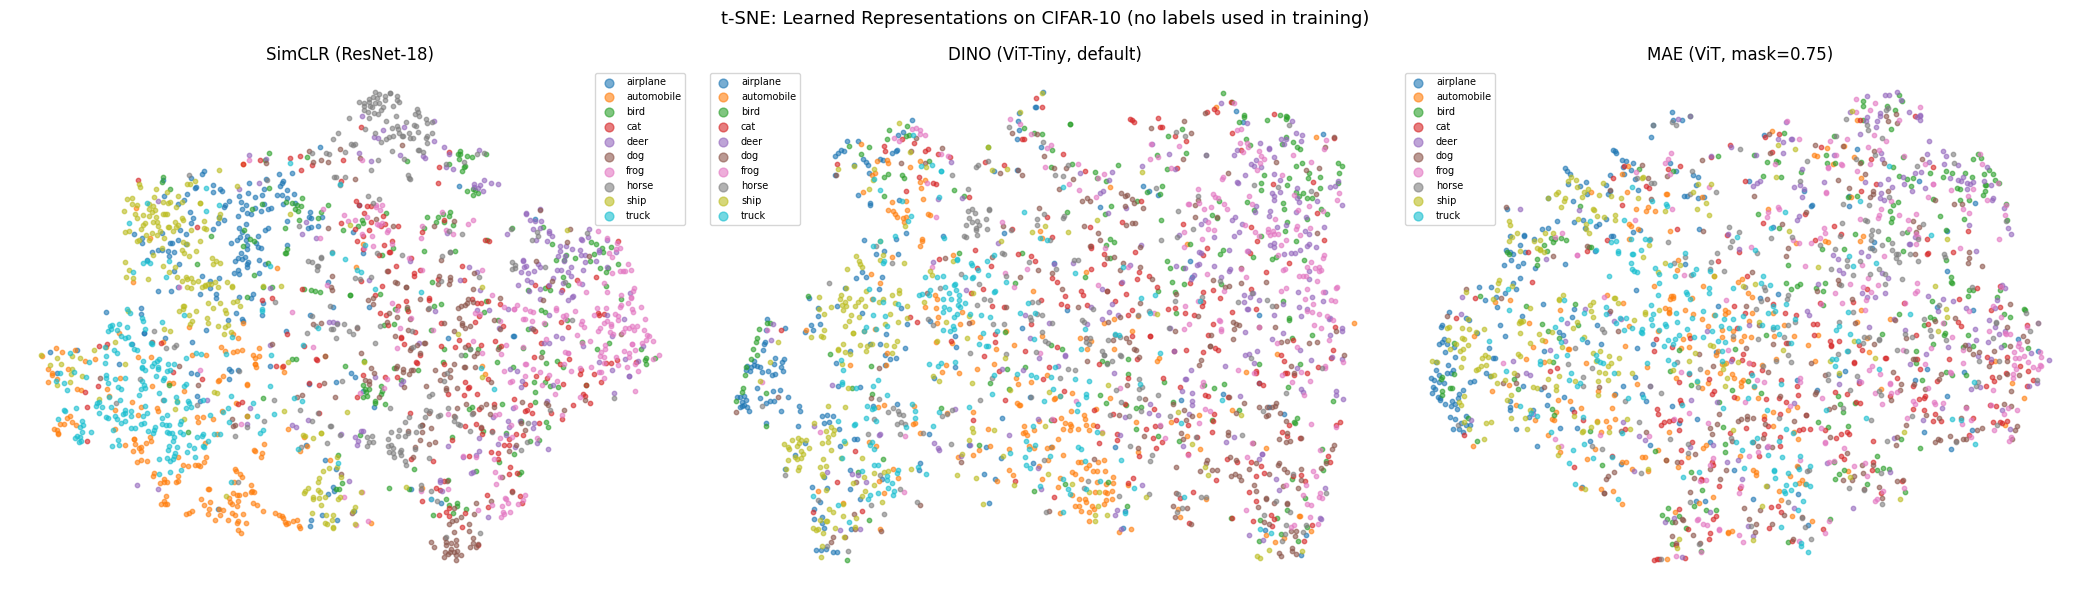

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))
colors = plt.cm.tab10(np.linspace(0, 1, 10))

tsne_sources = [
    ('SimCLR (ResNet-18)', simclr_embeddings, simclr_labels),
    ('DINO (ViT-Tiny, default)', dino_results['default']['embeddings'], dino_results['default']['labels']),
    ('MAE (ViT, mask=0.75)', mae_sweep_results[0.75]['embeddings'], mae_sweep_results[0.75]['labels']),
]

for ax, (name, emb, lbls) in zip(axes, tsne_sources):
    n = min(2000, len(emb))
    idx = np.random.choice(len(emb), n, replace=False)
    proj = TSNE(n_components=2, random_state=42, perplexity=30).fit_transform(emb[idx].numpy())
    for c in range(10):
        mask_c = lbls[idx].numpy() == c
        ax.scatter(proj[mask_c,0], proj[mask_c,1], c=[colors[c]], label=CLASSES[c], alpha=0.6, s=10)
    ax.set_title(name, fontsize=12)
    ax.legend(fontsize=7, markerscale=2)
    ax.axis('off')

plt.suptitle('t-SNE: Learned Representations on CIFAR-10 (no labels used in training)', fontsize=13)
plt.tight_layout(); plt.show()



In [37]:
tsne_quality_simclr = 4   # clear partial clustering: airplane, truck, automobile, ship form visible groups
tsne_quality_dino   = 2   # almost no visible clustering, colors are largely mixed throughout
tsne_quality_mae    = 2   # similarly mixed, marginal structure only at the edges

simclr_time_per_epoch = 86.0    # from Part 1 SimCLR training (avg/epoch)
dino_time_per_epoch   = 318.2   # DINO default variant (2 global + 4 local, centering on)
mae_time_per_epoch    = 23.6    # MAE mask_ratio=0.75 variant

print("| Metric | SimCLR | DINO | MAE |")
print("|---|---|---|---|")
print("| Backbone | ResNet-18 | ViT-Tiny | ViT |")
print("| Needs negative pairs? | Yes | No | No |")
print("| Needs EMA teacher? | No | Yes | No |")
print(f"| Linear Eval Accuracy | {simclr_acc:.2f}% | {dino_acc:.2f}% | {mae_acc:.2f}% |")
print(f"| Training time/epoch | {simclr_time_per_epoch:.1f}s | {dino_time_per_epoch:.1f}s | {mae_time_per_epoch:.1f}s |")
print(f"| t-SNE cluster quality (1-5) | {tsne_quality_simclr} | {tsne_quality_dino} | {tsne_quality_mae} |")
print("| Has interpretable attention maps? | No | Yes | No |")

| Metric | SimCLR | DINO | MAE |
|---|---|---|---|
| Backbone | ResNet-18 | ViT-Tiny | ViT |
| Needs negative pairs? | Yes | No | No |
| Needs EMA teacher? | No | Yes | No |
| Linear Eval Accuracy | 65.54% | 50.65% | 40.10% |
| Training time/epoch | 86.0s | 318.2s | 23.6s |
| t-SNE cluster quality (1-5) | 4 | 2 | 2 |
| Has interpretable attention maps? | No | Yes | No |
